In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("student_exam_data.csv")
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [4]:
df.shape

(500, 3)

In [6]:
df.describe()

,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['Pass/Fail'], axis=1), df["Pass/Fail"])

In [14]:
X_train.shape

(375, 2)

In [15]:
y_train.shape

(375,)

In [19]:
lr = LogisticRegression(penalty='l2', C=2)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred = lr.predict(X_test)

In [21]:
y_pred.shape

(125,)

In [22]:
y_test.shape

(125,)

In [23]:
from sklearn.metrics import log_loss

log_loss(y_test, y_pred)

4.325238406694059

In [24]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.88

In [25]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Previous Exam Score')

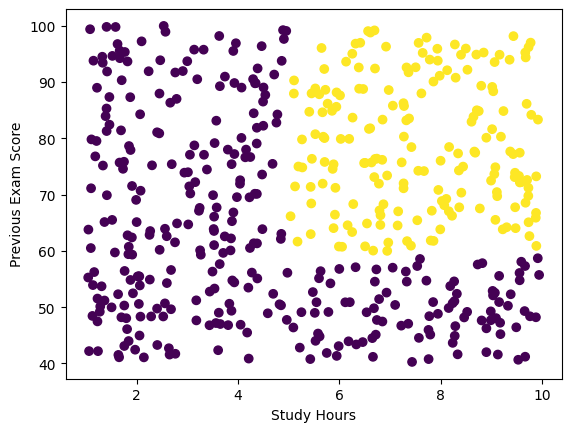

In [33]:
plt.scatter(df["Study Hours"], df["Previous Exam Score"], c=df["Pass/Fail"])
plt.xlabel("Study Hours")
plt.ylabel("Previous Exam Score")

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[76,  9],
       [ 6, 34]])

In [36]:
from sklearn.metrics import precision_score, recall_score

In [37]:
precision_score(y_test, y_pred)

0.7906976744186046

In [38]:
recall_score(y_test, y_pred)

0.85

In [39]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

In [42]:
print(f"""
thresholds: {thresholds}
Precision: {precision}
Recall: {recall}
""")


thresholds: [0 1]
Precision: [0.32       0.79069767 1.        ]
Recall: [1.   0.85 0.  ]

